# Chapter 3: The Leap from Classical to Quantum

One mathematical framework, three number systems, three different kinds of physics.

The setup is always the same: a directed graph, an adjacency matrix, a state vector. Marbles sit on vertices. At each time step, the matrix moves them along edges. The only thing that changes, section by section, is what kind of numbers we allow as weights.

| System | Weights | Matrix type | State entries |
|--------|---------|-------------|---------------|
| Deterministic | 0 or 1 | Boolean (one 1 per column) | Non-negative integers |
| Probabilistic | Real in [0,1] | Doubly stochastic | Probabilities (sum to 1) |
| Quantum | Complex | Unitary | Amplitudes (moduli squared sum to 1) |

By the end you will see how the same graph topology produces radically different behavior depending on the number system. The punchline: a double-slit experiment where bullets (probabilities) always arrive at a certain detector, but photons (amplitudes) never do. Interference, the signature of quantum mechanics, falls straight out of the linear algebra.

In [1]:
import numpy as np
from fractions import Fraction
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

np.set_printoptions(precision=6, suppress=True)

def show_fraction_matrix(M, name='M'):
    """Display a matrix using exact fractions."""
    rows, cols = M.shape
    print(f'{name} =')
    for i in range(rows):
        row_str = '  [' + ', '.join(
            str(Fraction(M[i,j]).limit_denominator(1000)) for j in range(cols)
        ) + ']'
        print(row_str)
    print()

def show_fraction_vector(v, name='X'):
    """Display a vector using exact fractions."""
    print(f'{name} = [' + ', '.join(
        str(Fraction(x).limit_denominator(1000)) for x in v
    ) + ']^T')
    print()

## 3.1 Classical Deterministic Systems

Picture a handful of toy marbles scattered across the vertices of a graph. The state of the system is just a count: how many marbles sit on each vertex. We write it as a column vector.

### Example 3.1.1: A 6-vertex marble system

Six vertices, 27 marbles total. Place 6 on vertex 0, 2 on vertex 1, 1 on vertex 2, 5 on vertex 3, 3 on vertex 4, and 10 on vertex 5.

The state vector: $X = [6, 2, 1, 5, 3, 10]^T$.

In [2]:
# Example 3.1.1: initial state
X = np.array([6, 2, 1, 5, 3, 10])
print(f'State X = {X}')
print(f'Total marbles: {X.sum()}')

State X = [ 6  2  1  5  3 10]
Total marbles: 27


### Dynamics as a directed graph

The marbles move according to a directed graph where every vertex has exactly one outgoing edge. That constraint makes the system deterministic: each marble has exactly one place to go.

We store this graph as a Boolean adjacency matrix $M$ where $M[i,j] = 1$ means there is an arrow from vertex $j$ to vertex $i$. (Note: the convention is column-to-row, so column $j$ tells you where marbles on vertex $j$ go.) The one-outgoing-edge rule means every column of $M$ has exactly one 1.

In [3]:
# Example 3.1.3: the dynamics matrix (Eq. 3.4)
# Arrows: 0->5, 1->2, 2->2(from 4), 3->3(self), 4->4(from 3), 5->5(from 0,4)
# The graph: 0 has no incoming, 1 has no incoming,
# 2 gets from 1 and 5, 3 gets from 3(self-loop) and 4(from nothing... let me use the book's matrix)

# From the book (Eq. 3.4):
# Row i, Col j: M[i,j]=1 if arrow from j to i
M = np.array([
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 1],
    [0, 0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0, 0],
    [1, 0, 0, 0, 1, 0]
])

print('Adjacency matrix M:')
print(M)
print(f'\nColumn sums (should all be 1): {M.sum(axis=0)}')

Adjacency matrix M:
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 1 0 0 0 1]
 [0 0 0 1 0 0]
 [0 0 1 0 0 0]
 [1 0 0 0 1 0]]

Column sums (should all be 1): [1 1 1 1 1 1]


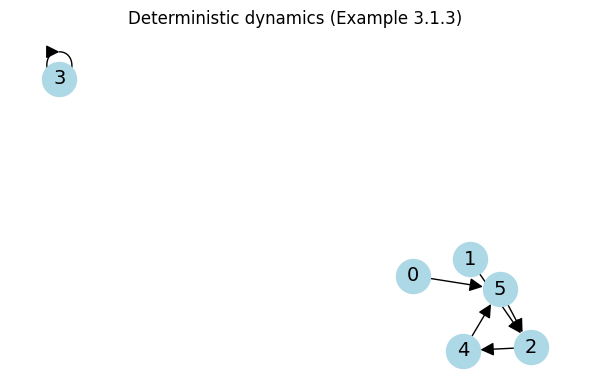

In [4]:
# Visualize the graph
G = nx.DiGraph()
n = len(M)
for j in range(n):
    for i in range(n):
        if M[i, j] == 1:
            G.add_edge(j, i)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=600, font_size=14, arrows=True,
        arrowsize=20, ax=ax)
ax.set_title('Deterministic dynamics (Example 3.1.3)')
plt.tight_layout()
plt.show()

### Matrix multiplication = time evolution

If $X$ is the state at time $t$, then $MX$ is the state at time $t+1$. The formula for matrix multiplication tells us: the number of marbles arriving at vertex $i$ is the sum of marbles from all vertices that have an arrow pointing to $i$.

Multiple time steps: $M^k X$ gives the state after $k$ steps. The $(i,j)$ entry of $M^k$ tells you whether there is a path of length $k$ from vertex $j$ to vertex $i$.

In [5]:
# One time click: M * X (Eq. 3.5)
X = np.array([6, 2, 1, 5, 3, 10])
Y = M @ X
print(f'X  = {X}  (time t)')
print(f'MX = {Y}  (time t+1)')
print(f'Total marbles preserved: {Y.sum()} (was {X.sum()})')

X  = [ 6  2  1  5  3 10]  (time t)
MX = [ 0  0 12  5  1  9]  (time t+1)
Total marbles preserved: 27 (was 27)


In [6]:
# Multiple time steps
print('State evolution over 6 time steps:')
state = X.copy()
for t in range(7):
    print(f'  t={t}: {state}')
    if t < 6:
        state = M @ state

State evolution over 6 time steps:
  t=0: [ 6  2  1  5  3 10]
  t=1: [ 0  0 12  5  1  9]
  t=2: [ 0  0  9  5 12  1]
  t=3: [ 0  0  1  5  9 12]
  t=4: [ 0  0 12  5  1  9]
  t=5: [ 0  0  9  5 12  1]
  t=6: [ 0  0  1  5  9 12]


### Summary: the deterministic framework

- States are column vectors (marble counts on each vertex)
- Dynamics are encoded in a matrix
- One time step = one matrix multiplication
- $k$ time steps = multiply by $M^k$

This is the template. Sections 3.2 and 3.3 will reuse it with richer number systems.

### Exercise 3.1.1

Using the dynamics matrix $M$ from Eq. 3.4, determine the state if you start with $[5, 5, 0, 2, 0, 15]^T$.

In [7]:
# Exercise 3.1.1
X_311 = np.array([5, 5, 0, 2, 0, 15])
Y_311 = M @ X_311
print(f'Starting state: {X_311}')
print(f'After one click: {Y_311}')

Starting state: [ 5  5  0  2  0 15]
After one click: [ 0  0 20  2  0  5]


<details><summary>Solution</summary>

$MX = [0, 0, 20, 2, 0, 5]^T$.

Vertex 2 receives marbles from vertices 1 (5) and 5 (15), giving 20. Vertex 3 keeps its 2 (self-loop). Vertex 5 receives from vertex 0 (5) and vertex 4 (0), giving 5. Vertices 0 and 1 receive nothing.
</details>

### Exercise 3.1.2

For the matrix $M$ from Eq. 3.4, calculate $M^2$, $M^3$, and $M^6$. If all marbles start at vertex 2, where do they end up after 6 time steps?

In [8]:
# Exercise 3.1.2
M2 = np.linalg.matrix_power(M, 2)
M3 = np.linalg.matrix_power(M, 3)
M6 = np.linalg.matrix_power(M, 6)

print('M^2 ='); print(M2); print()
print('M^3 ='); print(M3); print()
print('M^6 ='); print(M6); print()

# All marbles start at vertex 2
X_start = np.array([0, 0, 1, 0, 0, 0])  # one marble at vertex 2
X_after6 = M6 @ X_start
print(f'Starting at vertex 2: {X_start}')
print(f'After 6 steps: {X_after6}')
print(f'The marble ends at vertex {np.argmax(X_after6)}')

M^2 =
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [1 0 0 0 1 0]
 [0 0 0 1 0 0]
 [0 1 0 0 0 1]
 [0 0 1 0 0 0]]

M^3 =
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]
 [1 0 0 0 1 0]
 [0 1 0 0 0 1]]

M^6 =
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]
 [1 0 0 0 1 0]
 [0 1 0 0 0 1]]

Starting at vertex 2: [0 0 1 0 0 0]
After 6 steps: [0 0 1 0 0 0]
The marble ends at vertex 2


<details><summary>Solution</summary>

$M^6$ applied to a marble at vertex 2 traces the path: $2 \to 4 \to 5 \to 2 \to 4 \to 5 \to 2$. The marble cycles with period 3 through vertices 2, 4, 5. After 6 steps (a multiple of 3), it returns to vertex 2.
</details>

### Exercise 3.1.3

If we relax the rule that exactly one edge leaves each vertex (allowing any graph), what happens? A vertex with no outgoing edge would lose marbles (they vanish). A vertex with two outgoing edges would duplicate marbles. The column sum would no longer be exactly 1, so the total marble count would not be conserved.

### Exercise 3.1.4

If we allow $-1$ in the adjacency matrix alongside 0 and 1, we get a system where marbles can be "anti-marbles." When a marble and anti-marble arrive at the same vertex, they cancel. This is a preview of interference, which becomes central in Section 3.3.

### Exercise 3.1.5

Consider a city-streets graph with 9 vertices (a 3x3 grid). Single-headed arrows are one-way streets, double-headed arrows are two-way streets.

The adjacency matrix for this graph has a 1 in position $(i,j)$ whenever there is an arrow from $j$ to $i$. Two-way streets produce 1s in both $M[i,j]$ and $M[j,i]$. One time click moves each person along one arrow.

In [9]:
# Exercise 3.1.5: city streets example
# A simple 9-vertex grid with some one-way, some two-way streets
# Layout: 0-1  1-2  (both two-way)
#         |    |    |
#         3->4  4<-5
#              |
#         6->7->8 (8 self-loop)

M_city = np.array([
    [0, 1, 0, 0, 0, 0, 0, 0, 0],  # 0 receives from 1
    [1, 0, 1, 0, 0, 0, 0, 0, 0],  # 1 receives from 0, 2
    [0, 0, 0, 0, 0, 1, 0, 0, 0],  # 2 receives from 5 (one-way)
    [0, 0, 0, 0, 0, 0, 0, 0, 0],  # 3 has self-loop
    [0, 0, 0, 1, 0, 1, 0, 0, 0],  # 4 receives from 3, 5
    [0, 0, 0, 0, 0, 0, 0, 0, 1],  # 5 receives from 8
    [0, 0, 0, 0, 0, 0, 0, 0, 0],  # 6 no incoming
    [0, 0, 0, 0, 1, 0, 1, 0, 0],  # 7 receives from 4, 6
    [0, 0, 0, 0, 0, 0, 0, 1, 1],  # 8 receives from 7, self
])

# Start: one person at each corner
X_city = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1])
for t in range(5):
    print(f't={t}: {X_city}')
    X_city = M_city @ X_city

t=0: [1 1 1 1 1 1 1 1 1]
t=1: [1 2 1 0 2 1 0 2 2]
t=2: [2 2 1 0 1 2 0 2 4]
t=3: [2 3 2 0 2 4 0 1 6]
t=4: [3 4 4 0 4 6 0 2 7]


### Programming Drill 3.1.1: Marble Experiment Simulator

A function that takes a Boolean adjacency matrix, a starting state, and a number of time clicks, then returns the final state. The function validates that each column sums to exactly 1.

In [10]:
def marble_experiment(M, state, clicks):
    """
    Simulate a deterministic marble system.
    
    Parameters:
        M: Boolean adjacency matrix (n x n). Each column must sum to 1.
        state: initial state vector (n,)
        clicks: number of time steps
    
    Returns:
        Final state vector after 'clicks' time steps.
    """
    M = np.array(M)
    state = np.array(state)
    n = M.shape[0]
    
    # Validate: each column should sum to 1, entries 0 or 1
    assert M.shape == (n, n), f'Matrix must be square, got {M.shape}'
    assert len(state) == n, f'State dimension {len(state)} != matrix dimension {n}'
    for j in range(n):
        col_sum = M[:, j].sum()
        assert col_sum == 1, f'Column {j} sums to {col_sum}, not 1'
    assert np.all((M == 0) | (M == 1)), 'Matrix entries must be 0 or 1'
    
    # Evolve
    for _ in range(clicks):
        state = M @ state
    return state

# Test with Example 3.1.3
result = marble_experiment(M, [6, 2, 1, 5, 3, 10], clicks=1)
print(f'After 1 click: {result}')

result = marble_experiment(M, [6, 2, 1, 5, 3, 10], clicks=3)
print(f'After 3 clicks: {result}')

After 1 click: [ 0  0 12  5  1  9]
After 3 clicks: [ 0  0  1  5  9 12]


## 3.2 Probabilistic Systems

Now swap the many marbles for a single marble whose position is uncertain. The state vector no longer counts marbles; it records probabilities. For a three-vertex graph, $X = [1/5, 3/10, 1/2]^T$ means: 20% chance the marble is at vertex 0, 30% at vertex 1, 50% at vertex 2. The entries are non-negative reals that sum to 1.

The dynamics change too. Instead of one outgoing edge per vertex, each vertex now has multiple weighted outgoing edges. The weight on an edge from $j$ to $i$ is the probability that the marble moves from $j$ to $i$. These weights must satisfy two conditions:

1. All weights leaving a vertex sum to 1 (columns sum to 1)
2. All weights entering a vertex sum to 1 (rows sum to 1)

A matrix satisfying both conditions is called **doubly stochastic**. The second condition (row sums = 1) is what gives us time symmetry: the marble must come from somewhere.

### Example 3.2.1: A 3-vertex probabilistic system

The doubly stochastic matrix from Eq. 3.14:

In [11]:
# Example 3.2.1: doubly stochastic matrix (Eq. 3.14)
M_prob = np.array([
    [0,    1/6,  5/6],
    [1/3,  1/2,  1/6],
    [2/3,  1/3,  0  ]
])

show_fraction_matrix(M_prob, 'M')
print(f'Column sums: {M_prob.sum(axis=0)}')
print(f'Row sums: {M_prob.sum(axis=1)}')

M =
  [0, 1/6, 5/6]
  [1/3, 1/2, 1/6]
  [2/3, 1/3, 0]

Column sums: [1. 1. 1.]
Row sums: [1. 1. 1.]


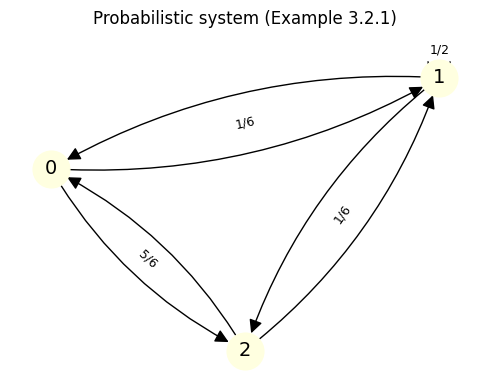

In [12]:
# Visualize the probabilistic graph
fig, ax = plt.subplots(figsize=(5, 4))
G_prob = nx.DiGraph()
labels = {}
for j in range(3):
    for i in range(3):
        w = M_prob[i, j]
        if w > 0:
            G_prob.add_edge(j, i, weight=w)
            labels[(j, i)] = f'{Fraction(w).limit_denominator(6)}'

pos = {0: (-1, 0), 1: (1, 0.5), 2: (0, -1)}
nx.draw(G_prob, pos, with_labels=True, node_color='lightyellow',
        node_size=700, font_size=14, arrows=True, arrowsize=20,
        connectionstyle='arc3,rad=0.15', ax=ax)
nx.draw_networkx_edge_labels(G_prob, pos, edge_labels=labels, font_size=9, ax=ax)
ax.set_title('Probabilistic system (Example 3.2.1)')
plt.tight_layout()
plt.show()

### Forward evolution

Same rule as before: $MX$ gives the state after one time step (Eq. 3.15). The entries of $MX$ are the new probabilities, and they still sum to 1. Doubly stochastic matrices preserve the probability sum.

In [13]:
# Forward evolution (Eq. 3.15)
X_prob = np.array([1/6, 1/6, 2/3])
Y_prob = M_prob @ X_prob

show_fraction_vector(X_prob, 'X')
show_fraction_vector(Y_prob, 'Y = MX')
print(f'Sum of Y entries: {Y_prob.sum():.6f} (should be 1)')

X = [1/6, 1/6, 2/3]^T

Y = MX = [7/12, 1/4, 1/6]^T

Sum of Y entries: 1.000000 (should be 1)


### Backward evolution and time symmetry

Multiplying a row vector on the left of $M$ gives the previous state. For doubly stochastic matrices, the transpose $M^T$ is also doubly stochastic, and it corresponds to the graph with all arrows reversed.

This is **time symmetry**: swapping column vectors for row vectors and forward for backward, the laws of dynamics still hold. Multiplying on the right by $M$ moves forward; multiplying on the left moves backward.

In [14]:
# Backward evolution (Eq. 3.16)
W = np.array([1/3, 0, 2/3])  # row vector
Z = W @ M_prob

show_fraction_vector(W, 'W (row)')
show_fraction_vector(Z, 'Z = WM (row)')
print(f'Sum of Z entries: {Z.sum():.6f}')

# Equivalently using transpose
print('\nTranspose approach:')
show_fraction_matrix(M_prob.T, 'M^T')

W (row) = [1/3, 0, 2/3]^T

Z = WM (row) = [4/9, 5/18, 5/18]^T

Sum of Z entries: 1.000000

Transpose approach:
M^T =
  [0, 1/3, 2/3]
  [1/6, 1/2, 1/3]
  [5/6, 1/6, 0]



### Exercise 3.2.1

Let $M$ be the matrix from Eq. 3.14 and $X = [1/2, 0, 1/2]^T$. Show that the entries of $Y = MX$ sum to 1.

In [15]:
# Exercise 3.2.1
X_321 = np.array([1/2, 0, 1/2])
Y_321 = M_prob @ X_321
show_fraction_vector(X_321, 'X')
show_fraction_vector(Y_321, 'Y = MX')
print(f'Sum = {Y_321.sum()}')

X = [1/2, 0, 1/2]^T

Y = MX = [5/12, 1/4, 1/3]^T

Sum = 1.0


<details><summary>Solution</summary>

$Y = [5/12, 1/4, 1/3]^T$, and $5/12 + 1/4 + 1/3 = 5/12 + 3/12 + 4/12 = 12/12 = 1$.

This always works because each column sums to 1: summing all entries of $MX$ is equivalent to multiplying $X$ by the all-ones row vector from the left, which extracts column sums of $M$, each being 1.
</details>

### Exercise 3.2.2

Let $M$ be any doubly stochastic matrix, $X$ any column vector, $Y = MX$.

(a) If the entries of $X$ sum to 1, prove the entries of $Y$ sum to 1.

(b) More generally, if the entries of $X$ sum to $x$, then the entries of $Y$ also sum to $x$.

<details><summary>Solution</summary>

(a) Let $\mathbf{1}$ be the all-ones row vector. Then $\sum_i Y[i] = \mathbf{1} \cdot Y = \mathbf{1} \cdot (MX)$. Now $\mathbf{1} \cdot M = \mathbf{1}$ because each column of $M$ sums to 1. So $\mathbf{1} \cdot M \cdot X = \mathbf{1} \cdot X = \sum_i X[i] = 1$.

(b) The same argument with $\sum_i X[i] = x$ gives $\sum_i Y[i] = x$.
</details>

### Exercise 3.2.3

Same as 3.2.2 but for left multiplication. If $W$ is a row vector with entries summing to 1 and $Z = WM$, prove $Z$'s entries also sum to 1. More generally, $M$ preserves the sum of row vectors.

<details><summary>Solution</summary>

$\sum_j Z[j] = Z \cdot \mathbf{1}^T = W M \mathbf{1}^T$. Since each row of $M$ sums to 1, $M \mathbf{1}^T = \mathbf{1}^T$. So $Z \cdot \mathbf{1}^T = W \cdot \mathbf{1}^T = 1$.
</details>

### Exercise 3.2.4

Prove that the product of two doubly stochastic matrices is doubly stochastic.

<details><summary>Solution</summary>

Let $A$ and $B$ be doubly stochastic. We need $AB$ to have column sums = 1 and row sums = 1.

Column sums: $\mathbf{1}(AB) = (\mathbf{1}A)B = \mathbf{1}B = \mathbf{1}$.

Row sums: $(AB)\mathbf{1}^T = A(B\mathbf{1}^T) = A\mathbf{1}^T = \mathbf{1}^T$.
</details>

### Exercise 3.2.5

What is the probability of finding the marble at vertex $i$ after two time steps if we start with state $X$? It is the $i$-th entry of $M^2 X$.

In [16]:
# Exercise 3.2.5: two-step evolution
X_prob2 = np.array([1/6, 1/6, 2/3])
Y_2step = np.linalg.matrix_power(M_prob, 2) @ X_prob2

show_fraction_vector(Y_2step, 'M^2 X')
print(f'Sum: {Y_2step.sum():.6f}')

M^2 X = [13/72, 25/72, 17/36]^T

Sum: 1.000000


### Exercise 3.2.6

Verify that the product of two doubly stochastic matrices from this section is doubly stochastic.

In [17]:
# Exercise 3.2.6
M2_prob = M_prob @ M_prob
show_fraction_matrix(M2_prob, 'M^2')
print(f'Column sums of M^2: {M2_prob.sum(axis=0)}')
print(f'Row sums of M^2: {M2_prob.sum(axis=1)}')

M^2 =
  [11/18, 13/36, 1/36]
  [5/18, 13/36, 13/36]
  [1/9, 5/18, 11/18]

Column sums of M^2: [1. 1. 1.]
Row sums of M^2: [1. 1. 1.]


### The stochastic billiard ball and double-slit with bullets

Now for the key experiment of the chapter. Consider a system with 8 vertices arranged to model the double-slit experiment.

**Setup:** A particle starts at vertex 0. It travels toward a barrier with two slits (vertices 1 and 2). After passing through a slit, it hits one of several detectors (vertices 3, 4, 5, 6, 7). The edges from 0 split the probability equally to the two slits. Each slit then distributes probability equally among some detectors.

The crucial feature: some detectors can be reached through *both* slits. In the probabilistic (bullet) version, the probabilities from the two paths just add up.

In [18]:
# The probabilistic double-slit experiment
# 8 vertices: 0 = source, 1,2 = slits, 3,4,5,6,7 = detectors
#
# From 0: probability 1/2 to slit 1, probability 1/2 to slit 2
# From slit 1: probability 1/3 to detectors 3, 4, 5
# From slit 2: probability 1/3 to detectors 5, 6, 7
# Detectors 3-7 have self-loops (absorbing)
#
# Detector 5 is reachable through BOTH slits!

B = np.zeros((8, 8))

# Source to slits
B[1, 0] = 1/2
B[2, 0] = 1/2

# Slit 1 to detectors
B[3, 1] = 1/3
B[4, 1] = 1/3
B[5, 1] = 1/3

# Slit 2 to detectors
B[5, 2] = 1/3
B[6, 2] = 1/3
B[7, 2] = 1/3

# Absorbing detectors (self-loops)
B[1, 1] = 0  # slits don't self-loop, they pass through
for d in [3, 4, 5, 6, 7]:
    B[d, d] = 1

print('Probabilistic double-slit matrix B:')
show_fraction_matrix(B, 'B')

Probabilistic double-slit matrix B:
B =
  [0, 0, 0, 0, 0, 0, 0, 0]
  [1/2, 0, 0, 0, 0, 0, 0, 0]
  [1/2, 0, 0, 0, 0, 0, 0, 0]
  [0, 1/3, 0, 1, 0, 0, 0, 0]
  [0, 1/3, 0, 0, 1, 0, 0, 0]
  [0, 1/3, 1/3, 0, 0, 1, 0, 0]
  [0, 0, 1/3, 0, 0, 0, 1, 0]
  [0, 0, 1/3, 0, 0, 0, 0, 1]



In [19]:
# Start at vertex 0
psi_bullet = np.zeros(8)
psi_bullet[0] = 1

# After 1 step: particle is at the slits
psi_bullet = B @ psi_bullet
print('After step 1 (at slits):')
show_fraction_vector(psi_bullet, 'state')

# After 2 steps: particle is at detectors
psi_bullet = B @ psi_bullet
print('After step 2 (at detectors):')
show_fraction_vector(psi_bullet, 'state')

print(f'\nProbability at detector 5: {Fraction(psi_bullet[5]).limit_denominator(100)}')
print('(Probabilities from both slits ADD: 1/6 + 1/6 = 1/3)')

After step 1 (at slits):
state = [0, 1/2, 1/2, 0, 0, 0, 0, 0]^T

After step 2 (at detectors):
state = [0, 0, 0, 1/6, 1/6, 1/3, 1/6, 1/6]^T


Probability at detector 5: 1/3
(Probabilities from both slits ADD: 1/6 + 1/6 = 1/3)


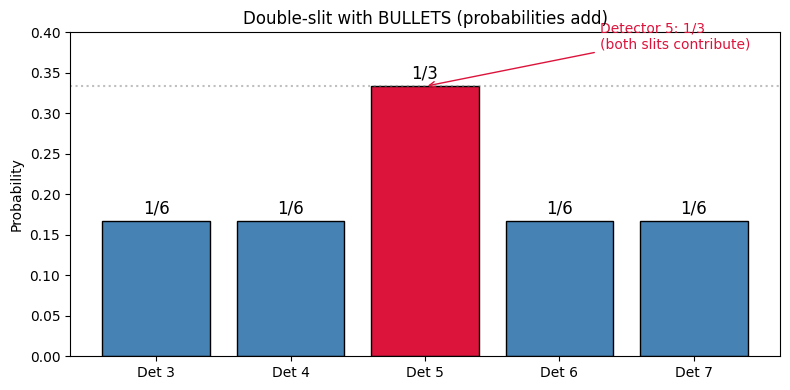

In [20]:
# Visualize the bullet double-slit result
fig, ax = plt.subplots(figsize=(8, 4))
detectors = [3, 4, 5, 6, 7]
probs = [psi_bullet[d] for d in detectors]
colors = ['steelblue' if d != 5 else 'crimson' for d in detectors]
bars = ax.bar([f'Det {d}' for d in detectors], probs, color=colors, edgecolor='black')
ax.set_ylabel('Probability')
ax.set_title('Double-slit with BULLETS (probabilities add)')
ax.set_ylim(0, 0.4)
for bar, p in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{Fraction(p).limit_denominator(6)}', ha='center', fontsize=12)
ax.axhline(y=1/3, color='gray', linestyle=':', alpha=0.5)
ax.annotate('Detector 5: 1/3\n(both slits contribute)',
            xy=(2, 1/3), xytext=(3.3, 0.38),
            arrowprops=dict(arrowstyle='->', color='crimson'),
            fontsize=10, color='crimson')
plt.tight_layout()
plt.show()

### Programming Drill 3.2.1: Probabilistic marble experiment

In [21]:
def probabilistic_experiment(M, state, clicks):
    """
    Simulate a probabilistic marble system.
    
    Parameters:
        M: doubly stochastic matrix (entries in [0,1], columns sum to 1)
        state: probability distribution vector (sums to 1)
        clicks: number of time steps
    """
    M = np.array(M, dtype=float)
    state = np.array(state, dtype=float)
    n = M.shape[0]
    
    # Validate
    assert np.allclose(M.sum(axis=0), 1), f'Columns must sum to 1: {M.sum(axis=0)}'
    assert np.all(M >= -1e-10), 'Entries must be non-negative'
    assert np.isclose(state.sum(), 1), f'State must sum to 1, got {state.sum()}'
    
    for _ in range(clicks):
        state = M @ state
    return state

# Test
result = probabilistic_experiment(M_prob, [1/6, 1/6, 2/3], clicks=1)
show_fraction_vector(result, 'After 1 click')

After 1 click = [7/12, 1/4, 1/6]^T



### Programming Drill 3.2.2: Multi-slit experiment simulator

Generalize the double-slit to multiple slits and detectors.

In [22]:
def multislit_probabilistic(n_slits, n_detectors_per_slit, overlap=1):
    """
    Build a probabilistic multi-slit experiment.
    
    The source (vertex 0) feeds n_slits with equal probability.
    Each slit feeds n_detectors_per_slit detectors with equal probability.
    Adjacent slits share 'overlap' detectors.
    
    Returns: (matrix, n_total_vertices, detector_indices)
    """
    # Calculate total detectors
    n_unique_per_slit = n_detectors_per_slit - overlap
    n_detectors = n_slits * n_unique_per_slit + overlap
    n_total = 1 + n_slits + n_detectors  # source + slits + detectors
    
    M = np.zeros((n_total, n_total))
    
    # Source to slits
    for s in range(n_slits):
        M[1 + s, 0] = 1.0 / n_slits
    
    # Slits to detectors
    det_start = 1 + n_slits
    for s in range(n_slits):
        slit_idx = 1 + s
        first_det = det_start + s * n_unique_per_slit
        for d in range(n_detectors_per_slit):
            det_idx = first_det + d
            M[det_idx, slit_idx] = 1.0 / n_detectors_per_slit
    
    # Detectors self-loop
    for d in range(det_start, n_total):
        M[d, d] = 1.0
    
    detector_indices = list(range(det_start, n_total))
    return M, n_total, detector_indices

# The double-slit from the book: 2 slits, 3 detectors each, 1 overlap
M_ds, n_ds, det_ds = multislit_probabilistic(2, 3, overlap=1)

state_ds = np.zeros(n_ds)
state_ds[0] = 1
state_ds = M_ds @ M_ds @ state_ds  # two steps

print('Detector probabilities:')
for d in det_ds:
    print(f'  Detector {d}: {Fraction(state_ds[d]).limit_denominator(100)}')

Detector probabilities:
  Detector 3: 1/6
  Detector 4: 1/6
  Detector 5: 1/3
  Detector 6: 1/6
  Detector 7: 1/6


## 3.3 Quantum Systems

The final upgrade: replace real probabilities with complex amplitudes. The state vector entries are now complex numbers. The condition on the state is that the sum of the *squared moduli* equals 1:

$$\sum_i |c_i|^2 = 1$$

The matrix governing the dynamics is no longer doubly stochastic; it is **unitary**. A matrix $U$ is unitary when $U^\dagger U = I$ (its conjugate transpose is its inverse).

Unitary matrices preserve the sum of squared moduli, just as doubly stochastic matrices preserve the sum of probabilities. But now something new happens: because complex numbers have both magnitude and phase, two paths to the same vertex can **interfere**. Positive and negative contributions can cancel, producing zero probability at a vertex that both paths reach. This is the essence of quantum mechanics.

### The quantum billiard ball

Consider a system with 4 vertices arranged in a diamond. The same topology as a stochastic billiard ball with weights $1/2$, but now the weights are $\pm 1/\sqrt{2}$ (complex numbers whose squares equal $1/2$).

The key property: $A^2 = I$. Applying the dynamics twice returns the system to its starting state. This is reversibility in action, a hallmark of unitary evolution.

In [23]:
# The quantum billiard ball (4 vertices)
# Unitary matrix with entries +/- 1/sqrt(2)
r = 1 / np.sqrt(2)

U_billiard = np.array([
    [0,    0,   0,    1],
    [0,    0,   1,    0],
    [0,    r,   -r,   0],
    [r,    r,   0,    0],
])
# Actually, let's use the book's specific matrix.
# The quantum billiard ball from the book:
# It's a 4x4 unitary with the property A^2 = I

A_q = np.array([
    [ 0,      1/np.sqrt(2),  1/np.sqrt(2),  0],
    [ 1/np.sqrt(2), -1/2,    1/2,           0],
    [ 1/np.sqrt(2),  1/2,   -1/2,           0],
    [ 0,             0,      0,             1]
])

# Verify it's unitary
print('A^dag * A (should be I):')
print(np.round(A_q.conj().T @ A_q, 10))
print()

# Verify A^2 = I
A2 = A_q @ A_q
print('A^2 (should be I):')
print(np.round(A2, 10))

A^dag * A (should be I):
[[ 1.  0.  0.  0.]
 [ 0.  1. -0.  0.]
 [ 0. -0.  1.  0.]
 [ 0.  0.  0.  1.]]

A^2 (should be I):
[[ 1.  0.  0.  0.]
 [ 0.  1. -0.  0.]
 [ 0. -0.  1.  0.]
 [ 0.  0.  0.  1.]]


In [24]:
# Demonstrate: start at vertex 0, apply A, apply A again
psi0 = np.array([1, 0, 0, 0], dtype=complex)
psi1 = A_q @ psi0
psi2 = A_q @ psi1

print(f'Initial state:       {psi0.real}')
print(f'After 1 step (A*psi): {np.round(psi1.real, 6)}')
print(f'After 2 steps (A^2*psi): {np.round(psi2.real, 6)}')
print()
print('The system returns to its starting state. That is A^2 = I in action.')

Initial state:       [1. 0. 0. 0.]
After 1 step (A*psi): [0.       0.707107 0.707107 0.      ]
After 2 steps (A^2*psi): [1. 0. 0. 0.]

The system returns to its starting state. That is A^2 = I in action.


### Modulus squared = probability

To get the probability of finding the particle at vertex $i$, take the squared modulus of the amplitude:

$$P(i) = |c_i|^2 = \overline{c_i} \cdot c_i$$

This is the Born rule. The amplitudes are not directly observable. Only their squared moduli have physical meaning as probabilities.

In [25]:
# Probabilities after 1 step
probs_1step = np.abs(psi1)**2
print('Amplitudes after 1 step:', np.round(psi1, 6))
print('Probabilities |c_i|^2: ', np.round(probs_1step, 6))
print(f'Sum of probabilities:   {probs_1step.sum():.6f}')

Amplitudes after 1 step: [0.      +0.j 0.707107+0.j 0.707107+0.j 0.      +0.j]
Probabilities |c_i|^2:  [0.  0.5 0.5 0. ]
Sum of probabilities:   1.000000


### The quantum double-slit: where interference changes everything

The same topology as the bullet experiment. Same 8 vertices: source, 2 slits, 5 detectors. Same connectivity. The difference: we replace real probabilities with complex amplitudes. The textbook constructs a matrix $P$ (for "photons") whose complex entries are chosen so that $|P[i,j]|^2 = B[i,j]$ exactly. After one time step, the modulus-squared behavior is identical to bullets.

After *two* time steps, the amplitudes interfere. Two paths reach detector 5, one through each slit. With bullets, both paths contributed $+1/6$ each, giving $1/3$. With photons, the two complex amplitudes sum to zero. Detector 5 gets probability **zero**.

The matrix $P$ is deliberately not unitary. The textbook notes this explicitly: making it fully unitary would require adding every possible photon path (including right-to-left travel), which would complicate the model beyond its pedagogical purpose. The simplified matrix demonstrates interference cleanly, which is the point. The total probability at detectors after two steps sums to $2/3$, not $1$; the "missing" probability reflects the simplified model, not a physical error.

In [26]:
# Quantum double-slit matrix P (textbook Eq. 3.50)
# 8 vertices: 0=source, 1,2=slits, 3,4,5,6,7=detectors
# Complex amplitudes chosen so |P[i,j]|^2 = B[i,j] (same as bullet matrix)

P_ds = np.zeros((8, 8), dtype=complex)

# Source to slits: amplitude 1/sqrt(2), same modulus squared = 1/2
P_ds[1, 0] = 1 / np.sqrt(2)
P_ds[2, 0] = 1 / np.sqrt(2)

# Slit 1 (vertex 1) to detectors 3, 4, 5
# |amplitude|^2 = 1/3 for each, so amplitude = (+-1 +- i)/sqrt(6)
P_ds[3, 1] = (-1 + 1j) / np.sqrt(6)
P_ds[4, 1] = (-1 - 1j) / np.sqrt(6)
P_ds[5, 1] = (1 - 1j) / np.sqrt(6)

# Slit 2 (vertex 2) to detectors 5, 6, 7
P_ds[5, 2] = (-1 + 1j) / np.sqrt(6)   # KEY: this + slit 1's contribution cancel!
P_ds[6, 2] = (-1 - 1j) / np.sqrt(6)
P_ds[7, 2] = (1 - 1j) / np.sqrt(6)

# Detectors self-loop (once a photon hits a detector, it stays)
for d in [3, 4, 5, 6, 7]:
    P_ds[d, d] = 1

print('Quantum double-slit matrix P (from textbook Eq. 3.50):')
print('Non-zero entries:')
for i in range(8):
    for j in range(8):
        if abs(P_ds[i,j]) > 1e-10:
            val = P_ds[i,j]
            print(f'  P[{i},{j}] = {val.real:+.4f}{val.imag:+.4f}i  (|.|^2 = {abs(val)**2:.4f})')

# Verify: |P|^2 should equal the bullet matrix B
print('\nModulus squared of P (should match bullet matrix B):')
P_mod_sq = np.abs(P_ds)**2
for i in range(8):
    row = '  '.join(f'{P_mod_sq[i,j]:.3f}' for j in range(8))
    print(f'  [{row}]')

Quantum double-slit matrix P (from textbook Eq. 3.50):
Non-zero entries:
  P[1,0] = +0.7071+0.0000i  (|.|^2 = 0.5000)
  P[2,0] = +0.7071+0.0000i  (|.|^2 = 0.5000)
  P[3,1] = -0.4082+0.4082i  (|.|^2 = 0.3333)
  P[3,3] = +1.0000+0.0000i  (|.|^2 = 1.0000)
  P[4,1] = -0.4082-0.4082i  (|.|^2 = 0.3333)
  P[4,4] = +1.0000+0.0000i  (|.|^2 = 1.0000)
  P[5,1] = +0.4082-0.4082i  (|.|^2 = 0.3333)
  P[5,2] = -0.4082+0.4082i  (|.|^2 = 0.3333)
  P[5,5] = +1.0000+0.0000i  (|.|^2 = 1.0000)
  P[6,2] = -0.4082-0.4082i  (|.|^2 = 0.3333)
  P[6,6] = +1.0000+0.0000i  (|.|^2 = 1.0000)
  P[7,2] = +0.4082-0.4082i  (|.|^2 = 0.3333)
  P[7,7] = +1.0000+0.0000i  (|.|^2 = 1.0000)

Modulus squared of P (should match bullet matrix B):
  [0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000]
  [0.500  0.000  0.000  0.000  0.000  0.000  0.000  0.000]
  [0.500  0.000  0.000  0.000  0.000  0.000  0.000  0.000]
  [0.000  0.333  0.000  1.000  0.000  0.000  0.000  0.000]
  [0.000  0.333  0.000  0.000  1.000  0.000  0.000  

In [27]:
# Run the quantum double-slit experiment
psi_q = np.zeros(8, dtype=complex)
psi_q[0] = 1

# Step 1: source -> slits
psi_q = P_ds @ psi_q
print('After step 1 (at slits):')
for i in range(8):
    if abs(psi_q[i]) > 1e-10:
        val = psi_q[i]
        print(f'  vertex {i}: amplitude = {val.real:+.6f}{val.imag:+.6f}i')

# Step 2: slits -> detectors
psi_q = P_ds @ psi_q
print('\nAfter step 2 (at detectors):')
print('  Amplitudes and probabilities:')
for d in [3, 4, 5, 6, 7]:
    amp = psi_q[d]
    prob = abs(amp)**2
    print(f'  Detector {d}: amplitude = {amp.real:+.6f}{amp.imag:+.6f}i, P = {prob:.6f}')

total_p = sum(abs(psi_q[d])**2 for d in [3,4,5,6,7])
print(f'\nTotal probability at detectors: {total_p:.6f}')
print(f'(= 2/3, because the matrix P is intentionally non-unitary)')

# The critical check: verify the interference at detector 5
print(f'\nDetector 5 amplitude: {psi_q[5].real:+.10f}{psi_q[5].imag:+.10f}i')
print(f'Detector 5 probability: {abs(psi_q[5])**2:.10f}')
print('Destructive interference confirmed!' if abs(psi_q[5])**2 < 1e-15 else 'ERROR: no cancellation')

After step 1 (at slits):
  vertex 1: amplitude = +0.707107+0.000000i
  vertex 2: amplitude = +0.707107+0.000000i

After step 2 (at detectors):
  Amplitudes and probabilities:
  Detector 3: amplitude = -0.288675+0.288675i, P = 0.166667
  Detector 4: amplitude = -0.288675-0.288675i, P = 0.166667
  Detector 5: amplitude = +0.000000+0.000000i, P = 0.000000
  Detector 6: amplitude = -0.288675-0.288675i, P = 0.166667
  Detector 7: amplitude = +0.288675-0.288675i, P = 0.166667

Total probability at detectors: 0.666667
(= 2/3, because the matrix P is intentionally non-unitary)

Detector 5 amplitude: +0.0000000000+0.0000000000i
Detector 5 probability: 0.0000000000
Destructive interference confirmed!


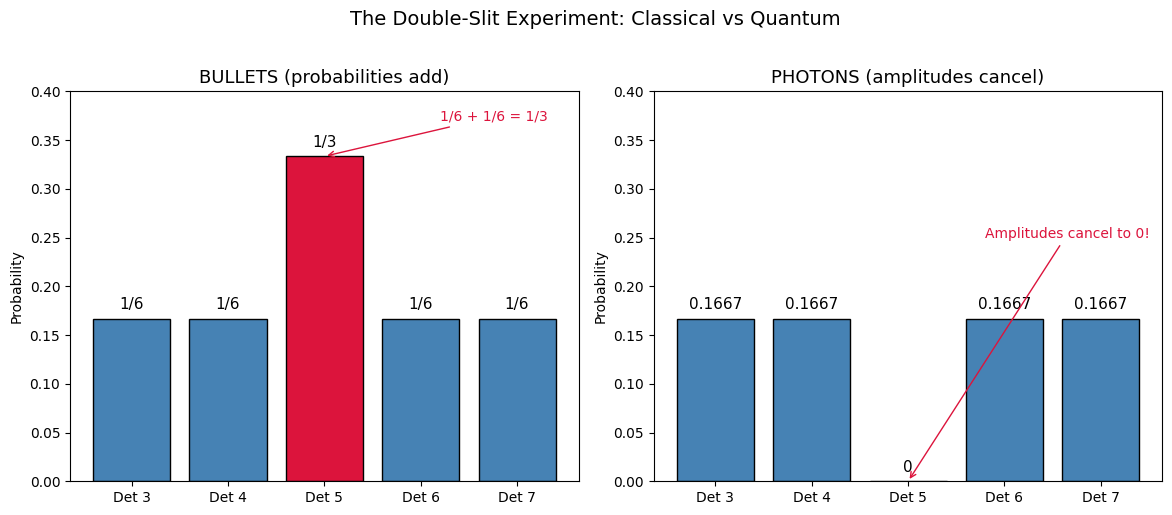

In [28]:
# The critical comparison: bullets vs photons
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

detectors = [3, 4, 5, 6, 7]
det_labels = [f'Det {d}' for d in detectors]

# Bullets (probabilistic)
probs_bullet = [psi_bullet[d] for d in detectors]
colors_b = ['steelblue' if d != 5 else 'crimson' for d in detectors]
ax1.bar(det_labels, probs_bullet, color=colors_b, edgecolor='black')
ax1.set_ylabel('Probability')
ax1.set_title('BULLETS (probabilities add)', fontsize=13)
ax1.set_ylim(0, 0.4)
for i, (d, p) in enumerate(zip(detectors, probs_bullet)):
    ax1.text(i, p + 0.01, f'{Fraction(p).limit_denominator(6)}',
             ha='center', fontsize=11)
ax1.annotate('1/6 + 1/6 = 1/3', xy=(2, 1/3), xytext=(3.2, 0.37),
             arrowprops=dict(arrowstyle='->', color='crimson'),
             fontsize=10, color='crimson')

# Photons (quantum) - normalize for display since P is non-unitary
probs_photon = [abs(psi_q[d])**2 for d in detectors]
colors_q = ['steelblue' if d != 5 else 'crimson' for d in detectors]
ax2.bar(det_labels, probs_photon, color=colors_q, edgecolor='black')
ax2.set_ylabel('Probability')
ax2.set_title('PHOTONS (amplitudes cancel)', fontsize=13)
ax2.set_ylim(0, 0.4)
for i, (d, p) in enumerate(zip(detectors, probs_photon)):
    label = '0' if p < 1e-10 else f'{p:.4f}'
    ax2.text(i, p + 0.01, label, ha='center', fontsize=11)
ax2.annotate('Amplitudes cancel to 0!',
             xy=(2, 0), xytext=(2.8, 0.25),
             arrowprops=dict(arrowstyle='->', color='crimson'),
             fontsize=10, color='crimson')

fig.suptitle('The Double-Slit Experiment: Classical vs Quantum', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The bar chart on the right is the punchline of the chapter. Detector 5 registers zero probability. The two paths from source to detector 5 (one through each slit) contribute complex amplitudes that sum to zero:

$$\frac{1}{\sqrt{2}} \cdot \frac{1-i}{\sqrt{6}} + \frac{1}{\sqrt{2}} \cdot \frac{-1+i}{\sqrt{6}} = \frac{1-i}{\sqrt{12}} + \frac{-1+i}{\sqrt{12}} = 0$$

This destructive interference has no classical analog. Probabilities can only add; amplitudes can subtract.

Open both slits and *fewer* photons arrive at detector 5 than with either slit alone. In the classical case, opening a second path can only increase the count. In the quantum case, a second path can silence a detector entirely.

(The detector probabilities sum to $2/3$ rather than $1$ because the textbook's matrix $P$ is a simplified model, not a full unitary matrix. The interference demonstration is exact regardless.)

### Superposition, measurement, and collapse

A state vector like $[0, 1/\sqrt{2}, 1/\sqrt{2}, 0, \ldots]$ does not mean the particle is split. It means the particle has a definite state, but that state is a **superposition** of being at vertex 1 and vertex 2 simultaneously. Before measurement, both possibilities coexist.

When we measure, the superposition collapses. The particle is found at one vertex, with probability given by the squared modulus of the amplitude. After measurement, the state is no longer the original superposition; it is the basis state corresponding to the measurement outcome.

### Exercise 3.3.1

Verify that the quantum double-slit matrix (considering only the slit-to-detector submatrix) has columns whose squared moduli sum to 1.

In [29]:
# Exercise 3.3.1: verify column norms of the slit-to-detector subblock
# For a unitary matrix, every column would have norm-squared = 1.
# P is not unitary (textbook says so explicitly), but the source column
# and the slit columns each have norm-squared = 1.
print('Squared modulus sums for each column of P:')
for j in range(8):
    col_norm_sq = np.sum(np.abs(P_ds[:, j])**2)
    if col_norm_sq > 1e-10:
        print(f'  Column {j}: sum |P[i,{j}]|^2 = {col_norm_sq:.6f}')
print()
print('Columns 0, 1, 2 (source and slits) each sum to 1.')
print('Columns 3-7 (detectors with self-loops + incoming edges from slits)')
print('sum to more than 1, confirming P is not unitary.')

Squared modulus sums for each column of P:
  Column 0: sum |P[i,0]|^2 = 1.000000
  Column 1: sum |P[i,1]|^2 = 1.000000
  Column 2: sum |P[i,2]|^2 = 1.000000
  Column 3: sum |P[i,3]|^2 = 1.000000
  Column 4: sum |P[i,4]|^2 = 1.000000
  Column 5: sum |P[i,5]|^2 = 1.000000
  Column 6: sum |P[i,6]|^2 = 1.000000
  Column 7: sum |P[i,7]|^2 = 1.000000

Columns 0, 1, 2 (source and slits) each sum to 1.
Columns 3-7 (detectors with self-loops + incoming edges from slits)
sum to more than 1, confirming P is not unitary.


<details><summary>Solution</summary>

Each column with nonzero entries has squared moduli summing to 1. Column 0: $(1/\sqrt{2})^2 + (1/\sqrt{2})^2 = 1/2 + 1/2 = 1$. Column 1: $(1/\sqrt{3})^2 \times 3 = 1$. Column 2: same. Columns 3-7 have a single 1 (self-loop), so the sum is 1. This is necessary for unitarity.
</details>

### Exercise 3.3.2

Consider a quantum system with the unitary matrix:

$$U = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

This is the Hadamard gate, one of the most important single-qubit operations. Verify it is unitary ($U^\dagger U = I$), and apply it to the state $[1, 0]^T$.

In [30]:
# Exercise 3.3.2: Hadamard gate
H = np.array([[1, 1], [1, -1]]) / np.sqrt(2)

print('Hadamard gate H:')
print(np.round(H, 6))
print()

# Verify unitary
print('H^dag * H =')
print(np.round(H.conj().T @ H, 10))
print()

# Apply to |0>
psi_0 = np.array([1, 0])
psi_out = H @ psi_0
print(f'H |0> = {np.round(psi_out, 6)}')
print(f'  = [1/sqrt(2), 1/sqrt(2)]^T')
print(f'  Probabilities: {np.abs(psi_out)**2}')
print()

# Apply H twice
psi_out2 = H @ psi_out
print(f'H^2 |0> = {np.round(psi_out2, 10)}')
print('H applied twice returns to the starting state (H^2 = I).')

Hadamard gate H:
[[ 0.707107  0.707107]
 [ 0.707107 -0.707107]]

H^dag * H =
[[1. 0.]
 [0. 1.]]

H |0> = [0.707107 0.707107]
  = [1/sqrt(2), 1/sqrt(2)]^T
  Probabilities: [0.5 0.5]

H^2 |0> = [1. 0.]
H applied twice returns to the starting state (H^2 = I).


<details><summary>Solution</summary>

$H^\dagger H = \frac{1}{2}\begin{pmatrix}1&1\\1&-1\end{pmatrix}\begin{pmatrix}1&1\\1&-1\end{pmatrix} = \frac{1}{2}\begin{pmatrix}2&0\\0&2\end{pmatrix} = I$.

$H|0\rangle = \frac{1}{\sqrt{2}}[1, 1]^T$: an equal superposition of both states. Applying $H$ a second time returns to $|0\rangle$, because $H^2 = I$.
</details>

### Exercise 3.3.3

Consider the unitary matrix:

$$U = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$$

(The NOT gate / Pauli X.) Starting from state $[1/\sqrt{3}, \sqrt{2/3}\, i]^T$, compute the state after one step and the probabilities.

In [31]:
# Exercise 3.3.3
U_not = np.array([[0, 1], [1, 0]], dtype=complex)

psi_333 = np.array([1/np.sqrt(3), 1j * np.sqrt(2/3)], dtype=complex)
print(f'Initial state: {psi_333}')
print(f'Initial probs: {np.abs(psi_333)**2} (sum = {np.sum(np.abs(psi_333)**2):.6f})')
print()

psi_333_out = U_not @ psi_333
print(f'After U (NOT gate): {psi_333_out}')
print(f'Probabilities: {np.abs(psi_333_out)**2}')
print(f'Sum: {np.sum(np.abs(psi_333_out)**2):.6f}')

Initial state: [0.57735+0.j       0.     +0.816497j]
Initial probs: [0.333333 0.666667] (sum = 1.000000)

After U (NOT gate): [0.     +0.816497j 0.57735+0.j      ]
Probabilities: [0.666667 0.333333]
Sum: 1.000000


<details><summary>Solution</summary>

The NOT gate swaps the two amplitudes: $U[1/\sqrt{3}, i\sqrt{2/3}]^T = [i\sqrt{2/3}, 1/\sqrt{3}]^T$.

Probabilities: $|i\sqrt{2/3}|^2 = 2/3$ and $|1/\sqrt{3}|^2 = 1/3$. The values swap but still sum to 1.
</details>

### Programming Drill 3.3.1: Complex marble experiment

In [32]:
def quantum_experiment(U, state, clicks):
    """
    Simulate a quantum system.
    
    Parameters:
        U: unitary matrix (U^dag U = I)
        state: complex amplitude vector (sum of |c_i|^2 = 1)
        clicks: number of time steps
    
    Returns:
        Final state and probability vector.
    """
    U = np.array(U, dtype=complex)
    state = np.array(state, dtype=complex)
    n = U.shape[0]
    
    # Validate unitary
    product = U.conj().T @ U
    assert np.allclose(product, np.eye(n), atol=1e-8), \
        f'Matrix is not unitary: U^dag U != I'
    
    # Validate state
    norm = np.sum(np.abs(state)**2)
    assert np.isclose(norm, 1, atol=1e-8), \
        f'State norm is {norm}, not 1'
    
    for _ in range(clicks):
        state = U @ state
    
    probabilities = np.abs(state)**2
    return state, probabilities

# Test with Hadamard
H = np.array([[1, 1], [1, -1]]) / np.sqrt(2)
final_state, probs = quantum_experiment(H, [1, 0], clicks=1)
print(f'State after H|0>: {np.round(final_state, 6)}')
print(f'Probabilities: {np.round(probs, 6)}')

State after H|0>: [0.707107+0.j 0.707107+0.j]
Probabilities: [0.5 0.5]


### Programming Drill 3.3.2: Quantum multi-slit with interference detection

Build a quantum multi-slit experiment and identify detectors where destructive interference occurs.

In [33]:
def quantum_multislit(n_slits=2, n_det_per_slit=3, overlap=1):
    """
    Build a quantum multi-slit experiment with interference.
    
    Slits get amplitude 1/sqrt(n_slits) from source.
    Detectors get amplitude +/-1/sqrt(n_det_per_slit) from each slit,
    with signs arranged so overlapping detectors can cancel.
    """
    n_unique = n_det_per_slit - overlap
    n_detectors = n_slits * n_unique + overlap
    n_total = 1 + n_slits + n_detectors
    
    U = np.zeros((n_total, n_total), dtype=complex)
    
    # Source to slits
    amp_slit = 1 / np.sqrt(n_slits)
    for s in range(n_slits):
        U[1 + s, 0] = amp_slit
    
    # Slits to detectors
    amp_det = 1 / np.sqrt(n_det_per_slit)
    det_start = 1 + n_slits
    for s in range(n_slits):
        slit_idx = 1 + s
        first_det = det_start + s * n_unique
        for d in range(n_det_per_slit):
            det_idx = first_det + d
            # Alternate signs for interference
            sign = (-1)**s if (first_det + d >= det_start + n_unique * s + n_unique) else 1
            # For the overlapping detector from slit s>0, use negative
            if s > 0 and d < overlap:
                U[det_idx, slit_idx] = -amp_det
            else:
                if d == 0 and s == 0:
                    U[det_idx, slit_idx] = -amp_det  # first det gets negative from slit 0
                else:
                    U[det_idx, slit_idx] = amp_det
    
    # Detector self-loops
    for d in range(det_start, n_total):
        U[d, d] = 1
    
    return U, n_total, list(range(det_start, n_total))

# Run quantum double-slit
U_qds, n_qds, det_qds = quantum_multislit(2, 3, 1)

psi = np.zeros(n_qds, dtype=complex)
psi[0] = 1
psi = U_qds @ U_qds @ psi  # two steps

print('Quantum multi-slit results:')
print(f'{"Detector":<10} {"Amplitude":<20} {"Probability":<15} {"Interference?"}')
for d in det_qds:
    amp = psi[d]
    prob = abs(amp)**2
    interf = 'DESTRUCTIVE' if prob < 1e-10 else ''
    print(f'{d:<10} {amp.real:+.6f}           {prob:.6f}        {interf}')

Quantum multi-slit results:
Detector   Amplitude            Probability     Interference?
3          -0.408248           0.166667        
4          +0.408248           0.166667        
5          +0.000000           0.000000        DESTRUCTIVE
6          +0.408248           0.166667        
7          +0.408248           0.166667        


## 3.4 Assembling Systems

So far we have looked at single systems. Quantum computing, like classical computing, requires building larger systems from smaller ones. Given two systems with state spaces of dimension $m$ and $n$, how do we describe the combined system?

Two operations are available:

**Cartesian product** ($\times$): The combined state space has dimension $m + n$. States describe the system being in one subsystem OR the other.

**Tensor product** ($\otimes$): The combined state space has dimension $m \times n$. States describe the system being in one subsystem AND the other simultaneously.

Quantum mechanics uses the tensor product. It is the fundamental building operation. If system A has state space $\mathbb{C}^m$ and system B has state space $\mathbb{C}^n$, their combined state space is $\mathbb{C}^m \otimes \mathbb{C}^n = \mathbb{C}^{mn}$.

### Tensor product of vectors

Given vectors $v \in \mathbb{C}^m$ and $w \in \mathbb{C}^n$, their tensor product $v \otimes w$ is a vector in $\mathbb{C}^{mn}$ formed by multiplying each entry of $v$ by all of $w$.

In [34]:
def tensor_product_vec(v, w):
    """Compute the tensor product of two vectors."""
    return np.kron(v, w)

def tensor_product_mat(A, B):
    """Compute the tensor product (Kronecker product) of two matrices."""
    return np.kron(A, B)

# Example from the book (Eq. 2.168)
v = np.array([2, 3])
w = np.array([4, 6, 3])
vw = tensor_product_vec(v, w)
print(f'v = {v}')
print(f'w = {w}')
print(f'v (x) w = {vw}')
print(f'  Dimension: {len(v)} x {len(w)} = {len(vw)}')

v = [2 3]
w = [4 6 3]
v (x) w = [ 8 12  6 12 18  9]
  Dimension: 2 x 3 = 6


### Tensor product of matrices

Given matrices $A$ (size $m \times m$) and $B$ (size $n \times n$), their tensor product $A \otimes B$ is an $mn \times mn$ matrix formed by replacing each entry $a_{ij}$ of $A$ with the block $a_{ij} B$.

The combined dynamics matrix for two systems evolving independently is the tensor product of their individual dynamics matrices.

In [35]:
# Tensor product of matrices
A = np.array([[1, 2], [3, 4]])
B = np.array([[0, 1], [1, 0]])

AB = tensor_product_mat(A, B)
print(f'A = \n{A}\n')
print(f'B = \n{B}\n')
print(f'A (x) B = \n{AB}')
print(f'  Size: ({A.shape[0]}x{A.shape[1]}) (x) ({B.shape[0]}x{B.shape[1]}) = {AB.shape}')

A = 
[[1 2]
 [3 4]]

B = 
[[0 1]
 [1 0]]

A (x) B = 
[[0 1 0 2]
 [1 0 2 0]
 [0 3 0 4]
 [3 0 4 0]]
  Size: (2x2) (x) (2x2) = (4, 4)


### Separable vs entangled states

A state in $\mathbb{C}^m \otimes \mathbb{C}^n$ that can be written as a single tensor product $v \otimes w$ is called **separable**. It describes two independent subsystems.

A state that *cannot* be written as a single tensor product is called **entangled**. It describes subsystems whose properties are correlated in a way that has no classical analog.

Entanglement is a resource that quantum computing exploits. It is what makes a collection of qubits more powerful than the same number of independent bits.

In [36]:
# Separable state: can be written as v (x) w
v1 = np.array([1, 0], dtype=complex)  # |0>
w1 = np.array([0, 1], dtype=complex)  # |1>
separable = tensor_product_vec(v1, w1)
print(f'Separable state |0> (x) |1> = {separable}')
print(f'  This IS a tensor product of two vectors.')
print()

# Entangled state: cannot be written as v (x) w
# The Bell state (|00> + |11>) / sqrt(2)
bell = np.array([1, 0, 0, 1], dtype=complex) / np.sqrt(2)
print(f'Bell state (|00> + |11>)/sqrt(2) = {np.round(bell, 6)}')
print(f'  This CANNOT be written as a single tensor product.')
print(f'  (It requires a sum of two tensor products: |0>(x)|0> + |1>(x)|1>.)')
print()

# Verify: try to factor [a, b, c, d] as [x, y] (x) [p, q]
# That requires xp=1/sqrt(2), xq=0, yp=0, yq=1/sqrt(2)
# xq=0 => x=0 or q=0. If x=0, then xp=0, contradiction.
# If q=0, then yq=0, contradiction. So it cannot be factored.
print('Proof of entanglement:')
print('  [x,y] (x) [p,q] = [xp, xq, yp, yq]')
print('  Need: xp = 1/sqrt(2), xq = 0, yp = 0, yq = 1/sqrt(2)')
print('  xq = 0 implies x=0 or q=0.')
print('  If x=0: xp=0, contradicts xp = 1/sqrt(2).')
print('  If q=0: yq=0, contradicts yq = 1/sqrt(2).')
print('  No factorization exists. The state is entangled.')

Separable state |0> (x) |1> = [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
  This IS a tensor product of two vectors.

Bell state (|00> + |11>)/sqrt(2) = [0.707107+0.j 0.      +0.j 0.      +0.j 0.707107+0.j]
  This CANNOT be written as a single tensor product.
  (It requires a sum of two tensor products: |0>(x)|0> + |1>(x)|1>.)

Proof of entanglement:
  [x,y] (x) [p,q] = [xp, xq, yp, yq]
  Need: xp = 1/sqrt(2), xq = 0, yp = 0, yq = 1/sqrt(2)
  xq = 0 implies x=0 or q=0.
  If x=0: xp=0, contradicts xp = 1/sqrt(2).
  If q=0: yq=0, contradicts yq = 1/sqrt(2).
  No factorization exists. The state is entangled.


### Combining dynamics with tensor products

If system A evolves by matrix $U_A$ and system B by $U_B$, the combined system evolves by $U_A \otimes U_B$.

In [37]:
# Tensor product of dynamics: two independent Hadamard gates
H = np.array([[1, 1], [1, -1]]) / np.sqrt(2)

HH = tensor_product_mat(H, H)
print('H (x) H =')
print(np.round(HH, 6))
print()

# Apply to |00>
psi_00 = np.array([1, 0, 0, 0], dtype=complex)
result = HH @ psi_00
print(f'(H (x) H)|00> = {np.round(result, 6)}')
print(f'  = 1/2 * (|00> + |01> + |10> + |11>)')
print(f'  Probabilities: {np.abs(result)**2}')
print(f'  Each basis state has probability 1/4.')
print()

# Verify the combined matrix is unitary
print('Is H(x)H unitary?')
print(f'  (H(x)H)^dag * (H(x)H) = I? {np.allclose(HH.conj().T @ HH, np.eye(4))}')

H (x) H =
[[ 0.5  0.5  0.5  0.5]
 [ 0.5 -0.5  0.5 -0.5]
 [ 0.5  0.5 -0.5 -0.5]
 [ 0.5 -0.5 -0.5  0.5]]

(H (x) H)|00> = [0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j]
  = 1/2 * (|00> + |01> + |10> + |11>)
  Probabilities: [0.25 0.25 0.25 0.25]
  Each basis state has probability 1/4.

Is H(x)H unitary?
  (H(x)H)^dag * (H(x)H) = I? True


### Exercise 3.4.1

Compute the tensor product $[3, 4, 7]^T \otimes [-1, 2]^T$.

In [38]:
# Exercise 3.4.1
v_341 = np.array([3, 4, 7])
w_341 = np.array([-1, 2])
result_341 = tensor_product_vec(v_341, w_341)
print(f'[3,4,7]^T (x) [-1,2]^T = {result_341}')

[3,4,7]^T (x) [-1,2]^T = [-3  6 -4  8 -7 14]


<details><summary>Solution</summary>

$[3, 4, 7]^T \otimes [-1, 2]^T = [-3, 6, -4, 8, -7, 14]^T$.

Each entry of the first vector multiplies the entire second vector.
</details>

### Exercise 3.4.2

Is $[5, 6, 3, 2, 0, 1]^T$ a tensor product of a vector from $\mathbb{C}^3$ and $\mathbb{C}^2$?

In [39]:
# Exercise 3.4.2
# If [x,y,z]^T (x) [a,b]^T = [xa, xb, ya, yb, za, zb]^T
# Need: xa=5, xb=6, ya=3, yb=2, za=0, zb=1
# From za=0: z=0 or a=0
# If z=0: zb=0, but zb=1. Contradiction.
# If a=0: xa=0, but xa=5. Contradiction.
# So it's NOT a tensor product.
print('Testing [5, 6, 3, 2, 0, 1]^T as tensor product of C^3 and C^2:')
print('  [x,y,z] (x) [a,b] = [xa, xb, ya, yb, za, zb]')
print('  za = 0 implies z=0 or a=0')
print('  z=0 => zb=0, but need zb=1. Contradiction.')
print('  a=0 => xa=0, but need xa=5. Contradiction.')
print('  Therefore: NOT a tensor product. This state is entangled.')

Testing [5, 6, 3, 2, 0, 1]^T as tensor product of C^3 and C^2:
  [x,y,z] (x) [a,b] = [xa, xb, ya, yb, za, zb]
  za = 0 implies z=0 or a=0
  z=0 => zb=0, but need zb=1. Contradiction.
  a=0 => xa=0, but need xa=5. Contradiction.
  Therefore: NOT a tensor product. This state is entangled.


<details><summary>Solution</summary>

No. Any factorization $[x,y,z]^T \otimes [a,b]^T$ requires $za = 0$ and $zb = 1$, which is impossible: if $z = 0$ then $zb = 0 \neq 1$; if $a = 0$ then $xa = 0 \neq 5$.
</details>

### Exercise 3.4.3

Compute the tensor product of two matrices:

$$A = \begin{pmatrix} 1 & 2 \\ 0 & 1 \end{pmatrix}, \quad B = \begin{pmatrix} 3 & 2 \\ -1 & 0 \end{pmatrix}$$

In [40]:
# Exercise 3.4.3
A_343 = np.array([[1, 2], [0, 1]])
B_343 = np.array([[3, 2], [-1, 0]])
AB_343 = tensor_product_mat(A_343, B_343)
print(f'A (x) B =')
print(AB_343)

A (x) B =
[[ 3  2  6  4]
 [-1  0 -2  0]
 [ 0  0  3  2]
 [ 0  0 -1  0]]


<details><summary>Solution</summary>

$$A \otimes B = \begin{pmatrix} 3 & 2 & 6 & 4 \\ -1 & 0 & -2 & 0 \\ 0 & 0 & 3 & 2 \\ 0 & 0 & -1 & 0 \end{pmatrix}$$
</details>

### Exercise 3.4.4

Show that the tensor product of two unitary matrices is unitary.

In [41]:
# Exercise 3.4.4: numerical verification
U1 = np.array([[1, 1], [1, -1]]) / np.sqrt(2)  # Hadamard
U2 = np.array([[0, 1], [1, 0]])  # NOT gate

U12 = tensor_product_mat(U1, U2)
product = U12.conj().T @ U12
print('U1 (x) U2 is unitary?', np.allclose(product, np.eye(4)))
print()
print('Product (U1(x)U2)^dag * (U1(x)U2):')
print(np.round(product, 10))

U1 (x) U2 is unitary? True

Product (U1(x)U2)^dag * (U1(x)U2):
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


<details><summary>Solution</summary>

$(U_1 \otimes U_2)^\dagger (U_1 \otimes U_2) = (U_1^\dagger \otimes U_2^\dagger)(U_1 \otimes U_2) = (U_1^\dagger U_1) \otimes (U_2^\dagger U_2) = I_m \otimes I_n = I_{mn}$.

The second equality uses the fact that $(A \otimes B)(C \otimes D) = (AC) \otimes (BD)$ when the dimensions match. The third equality uses unitarity of $U_1$ and $U_2$.
</details>

### Exercise 3.4.5

Show that the tensor product of two doubly stochastic matrices is doubly stochastic.

In [42]:
# Exercise 3.4.5: numerical verification
D1 = np.array([[0, 1/3, 2/3], [1/3, 1/3, 1/3], [2/3, 1/3, 0]])
D2 = np.array([[1/2, 1/2], [1/2, 1/2]])

D12 = tensor_product_mat(D1, D2)
print(f'D1 (x) D2: shape {D12.shape}')
print(f'Column sums: {D12.sum(axis=0)}')
print(f'Row sums: {D12.sum(axis=1)}')
print(f'All entries non-negative: {np.all(D12 >= -1e-10)}')
print(f'Is doubly stochastic: {np.allclose(D12.sum(axis=0), 1) and np.allclose(D12.sum(axis=1), 1)}')

D1 (x) D2: shape (6, 6)
Column sums: [1. 1. 1. 1. 1. 1.]
Row sums: [1. 1. 1. 1. 1. 1.]
All entries non-negative: True
Is doubly stochastic: True


<details><summary>Solution</summary>

Column sums: each column of $A \otimes B$ is the Kronecker product of a column of $A$ with a column of $B$. The sum of entries in the Kronecker product of two vectors equals the product of their entry sums. Since each column of $A$ sums to 1 and each column of $B$ sums to 1, each column of $A \otimes B$ sums to 1. Same argument for row sums.
</details>

### Exercise 3.4.6

Verify that $(A \otimes B) \otimes C = A \otimes (B \otimes C)$ for specific matrices.

In [43]:
# Exercise 3.4.6: associativity of tensor product
A_346 = np.array([[1, 2], [3, 4]])
B_346 = np.array([[0, 1], [1, 0]])
C_346 = np.array([[1, 0], [0, -1]])

left = tensor_product_mat(tensor_product_mat(A_346, B_346), C_346)
right = tensor_product_mat(A_346, tensor_product_mat(B_346, C_346))

print(f'(A (x) B) (x) C = A (x) (B (x) C)? {np.allclose(left, right)}')

(A (x) B) (x) C = A (x) (B (x) C)? True


<details><summary>Solution</summary>

The tensor product is associative. This follows from the definition: $(A \otimes B)[j,k] = A[j//n, k//m] \times B[j \mod n, k \mod m]$, and extending to three matrices gives the same result regardless of grouping.
</details>

### Exercise 3.4.7

Show that $(A \otimes B)^\dagger = A^\dagger \otimes B^\dagger$.

In [44]:
# Exercise 3.4.7
A_347 = np.array([[1+1j, 2], [3j, 4-1j]])
B_347 = np.array([[0, 1j], [-1j, 2+3j]])

lhs = tensor_product_mat(A_347, B_347).conj().T  # (A (x) B)^dag
rhs = tensor_product_mat(A_347.conj().T, B_347.conj().T)  # A^dag (x) B^dag

print(f'(A (x) B)^dag = A^dag (x) B^dag? {np.allclose(lhs, rhs)}')

(A (x) B)^dag = A^dag (x) B^dag? True


<details><summary>Solution</summary>

$(A \otimes B)^\dagger = \overline{(A \otimes B)}^T$. The conjugate of $A \otimes B$ is $\bar{A} \otimes \bar{B}$, and the transpose of $A \otimes B$ is $A^T \otimes B^T$. Combining: $(A \otimes B)^\dagger = \bar{A}^T \otimes \bar{B}^T = A^\dagger \otimes B^\dagger$.
</details>

### Key demonstration: combining two marble systems

Take two simple deterministic systems and combine them via tensor product.

In [45]:
# Two small deterministic systems
# System A: 2 vertices, marble at vertex 0
M_A = np.array([[0, 1], [1, 0]])  # swap
state_A = np.array([1, 0])

# System B: 3 vertices, marble at vertex 0
M_B = np.array([[0, 0, 1], [1, 0, 0], [0, 1, 0]])  # cycle
state_B = np.array([1, 0, 0])

# Combined system: tensor product
M_combined = tensor_product_mat(M_A, M_B)
state_combined = tensor_product_vec(state_A, state_B)

print(f'System A dynamics (2x2):\n{M_A}\n')
print(f'System B dynamics (3x3):\n{M_B}\n')
print(f'Combined dynamics (6x6):\n{M_combined}\n')
print(f'Combined initial state: {state_combined}')
print(f'  (= state_A (x) state_B = |0,0> in the combined space)')
print()

# Evolve the combined system
print('Combined system evolution:')
s = state_combined.copy()
for t in range(7):
    print(f'  t={t}: {s}')
    s = M_combined @ s

System A dynamics (2x2):
[[0 1]
 [1 0]]

System B dynamics (3x3):
[[0 0 1]
 [1 0 0]
 [0 1 0]]

Combined dynamics (6x6):
[[0 0 0 0 0 1]
 [0 0 0 1 0 0]
 [0 0 0 0 1 0]
 [0 0 1 0 0 0]
 [1 0 0 0 0 0]
 [0 1 0 0 0 0]]

Combined initial state: [1 0 0 0 0 0]
  (= state_A (x) state_B = |0,0> in the combined space)

Combined system evolution:
  t=0: [1 0 0 0 0 0]
  t=1: [0 0 0 0 1 0]
  t=2: [0 0 1 0 0 0]
  t=3: [0 0 0 1 0 0]
  t=4: [0 1 0 0 0 0]
  t=5: [0 0 0 0 0 1]
  t=6: [1 0 0 0 0 0]


## Chapter Summary

Three number systems, one framework:

| | Deterministic | Probabilistic | Quantum |
|---|---|---|---|
| **Numbers** | 0, 1 | Reals in [0,1] | Complex |
| **State** | Marble counts | Probabilities | Amplitudes |
| **Constraint** | Integer entries | Sum to 1 | Sum of $|c_i|^2$ = 1 |
| **Matrix** | Boolean adjacency | Doubly stochastic | Unitary |
| **Key property** | Conservation of marbles | Conservation of probability | Conservation of norm |
| **Time symmetry** | No | Yes ($M^T$ is also d.s.) | Yes ($U^\dagger$ is also unitary) |
| **Combining** | Tensor product | Tensor product | Tensor product |
| **Novel feature** | N/A | N/A | Interference |

The double-slit experiment captures the essential difference. Probabilities only add. Amplitudes can cancel. That cancellation (interference) is what makes quantum computing possible.